# ♟️ Össze játszma vizualizációja

Ez a notebook a `02_analysis.py` által generált `stats.json` és a `03_stockfish_analysis.py` által generált `stockfish_analysis.json` fájlokat jeleníti meg interaktív Plotly grafikonokkal.

**Futtatás előtt:** Győződj meg róla, hogy a pipeline 1-3. lépései lefutottak.

---

In [10]:
import subprocess, sys, os

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)
import config

if not os.path.exists(config.STATS_JSON):
    print("stats.json nem található – pipeline futtatása...")
    result = subprocess.run(
        [sys.executable, os.path.join(root_dir, "src", "run_pipeline.py"), "--pgn", config.PGN_FILE],
        cwd=root_dir,
    )
    if result.returncode != 0:
        raise RuntimeError("Pipeline futtatása sikertelen! Ellenőrizd a PGN fájlt és a config.py-t.")
    print("✅ Pipeline kész.")
else:
    print(f"✅ Adatok már megvannak: {config.STATS_JSON}")

✅ Adatok már megvannak: D:\Workspace\chess-pgn-analysis\output\analysis\stats.json


## 1. Előkészítés és adatok betöltése

In [11]:
import sys, os
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)
import config

import json
import math
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

if not os.path.exists(config.STATS_JSON):
    raise FileNotFoundError(
        f"Nem található a statisztika fájl: {config.STATS_JSON}. "
        "Futtasd a pipeline 2. lépését: python src/run_pipeline.py --pgn sakkpartik.pgn"
    )
with open(config.STATS_JSON, encoding='utf-8') as f:
    stats = json.load(f)
sf_data = {}
if os.path.exists(config.STOCKFISH_JSON):
    with open(config.STOCKFISH_JSON, encoding='utf-8') as f:
        sf_data = json.load(f)


TOTAL = stats.get('total_games', 0)
print(f'   Stockfish elemzés: {"igen" if sf_data.get("evaluations") else "nem elérhető"}')

THEME = config.PLOT_THEME
print(f'✅ Adatok betöltve. Összes játszma: {TOTAL:,}')

   Stockfish elemzés: nem elérhető
✅ Adatok betöltve. Összes játszma: 1,377


## 2. Sakkjátszmák hossza

### 2.1 Az én játszmáim hossza (PLY-ban, azaz féllépésben)

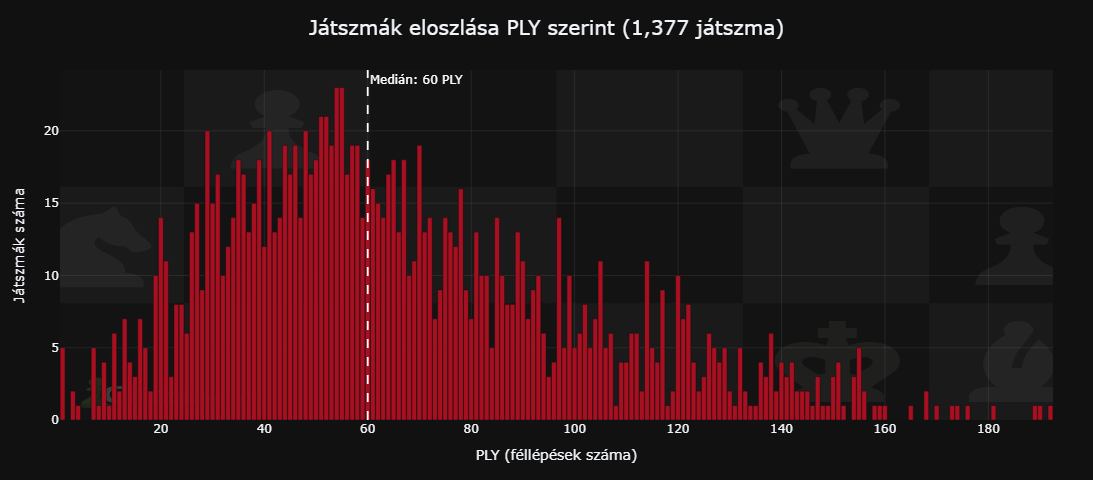

In [12]:
import base64, io
from PIL import Image

# Háttérkép base64-be
_img = Image.open(os.path.join(root_dir, 'notebooks', 'notebooks_src', 'bg1.png')).convert('RGB')
_buf = io.BytesIO()
_img.save(_buf, format='PNG')
_bg = 'data:image/png;base64,' + base64.b64encode(_buf.getvalue()).decode()

dist  = stats.get('move_count_dist', [])
mv_st = stats.get('move_stats', {})

if not dist:
    print('Nincs adat.')
else:
    df = pd.DataFrame(dist).sort_values('num_moves')

    fig = go.Figure(go.Bar(
        x=df['num_moves'],
        y=df['count'],
        marker_color='#A81022',
        hovertemplate='%{x} PLY → %{y:,} játszma<extra></extra>',
    ))

    median = mv_st.get('median_moves')
    if median is not None:
        fig.add_vline(
            x=float(median),
            line=dict(color='#ffffff', dash='dash', width=1.8),
            annotation_text=f'Medián: {float(median):.0f} PLY',
            annotation_font=dict(size=12, color='#ffffff'),
            annotation_position='top right',
        )

    fig.add_layout_image(dict(
        source=_bg,
        xref='paper', yref='paper',
        x=0, y=1, sizex=1, sizey=1,
        sizing='stretch',
        opacity=0.18,
        layer='below',
    ))

    fig.update_layout(
        title=dict(
            text=f'Játszmák eloszlása PLY szerint ({TOTAL:,} játszma)',
            font=dict(size=20),
            x=0.5,
            xanchor='center',
        ),
        xaxis=dict(
            title='PLY (féllépések száma)',
            gridcolor='rgba(255,255,255,0.08)',
            zeroline=False,
        ),
        yaxis=dict(
            title='Játszmák száma',
            gridcolor='rgba(255,255,255,0.08)',
            zeroline=False,
        ),
        template=THEME,
        plot_bgcolor='rgba(0,0,0,0)',
        height=480,
        bargap=0.06,
        showlegend=False,
        margin=dict(l=60, r=40, t=70, b=60),
    )

    fig.show()
    # fig.write_html(os.path.join(config.PLOTS_DIR, 'ply_distribution.html'))


## 2.2 Score sheet - avagy milyen hosszú játszmára lett kitalálva?

Az esetek __ %-ában nem kellett volna új játszmalapot kérnem, ha OTB (over the board) játszmák lettek volna az online játszott partijaim. :)

<Official Chess.com Score Sheet.pdf fájl megjelenítése notebooks/notebooks_src-ből>

## 3. Megnyitás-repertoár térkép (Sankey-diagram)

**Olvasási útmutató:**
- A csomópontok **zöldje** = magas győzelmi arány, **pirosa** = alacsony győzelmi arány az adott vonalban.
- Az élek vastagsága arányos a lejátszott játszmák számával.
- Bal oldal: a játékos **színe**; közép: az **első lépés csoportja**; jobb: az egyes **ECO megnyitás-kódok**.
- Hover = részletes győzelem / vereség / döntetlen statisztika.


Elemzett játékos: Wujajin


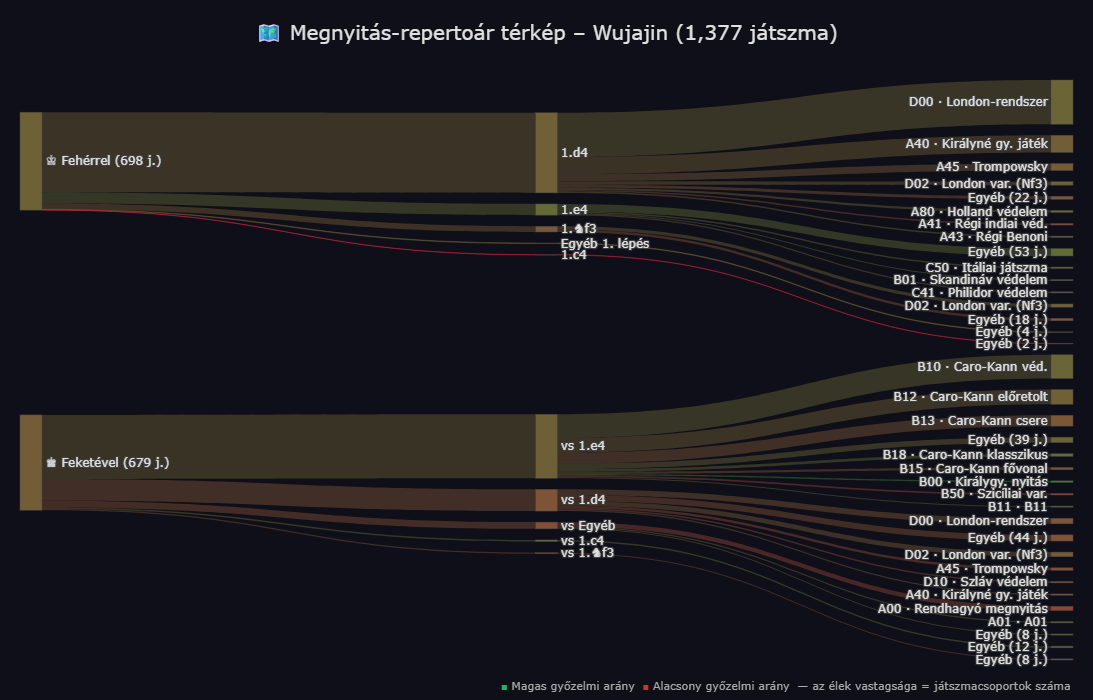

In [13]:
import chess.pgn
from collections import defaultdict, Counter
import plotly.graph_objects as go
import os

# ── ECO nevek (magyar) ────────────────────────────────────────────────────────
ECO_LABEL = {
    'D00': 'London-rendszer',       'D02': 'London var. (Nf3)',
    'D03': 'Torre-támadás',         'D10': 'Szláv védelem',
    'A40': 'Királyné gy. játék',    'A41': 'Régi indiai véd.',
    'A43': 'Régi Benoni',           'A45': 'Trompowsky',
    'A48': 'Királyindiai felállás', 'A80': 'Holland védelem',
    'A04': 'Réti-megnyitás var.',   'A00': 'Rendhagyó megnyitás',
    'B10': 'Caro-Kann véd.',        'B12': 'Caro-Kann előretolt',
    'B13': 'Caro-Kann csere',       'B15': 'Caro-Kann fővonal',
    'B18': 'Caro-Kann klasszikus',  'B00': 'Királygy. nyitás',
    'B01': 'Skandináv védelem',     'B07': 'Pirc védelem',
    'B50': 'Szicíliai var.',        'C41': 'Philidor védelem',
    'C50': 'Itáliai játszma',       'C45': 'Skót játszma',
}

def _wr_color(wr, alpha=0.85):
    r = int(220 * (1 - wr) + 40 * wr)
    g = int(40  * (1 - wr) + 180 * wr)
    return f'rgba({r},{g},60,{alpha})'

# ── PGN betöltés + játékos detektálás ────────────────────────────────────────
_pgn = os.path.join(root_dir, 'sakkpartik.pgn')
if not os.path.exists(_pgn):
    _pgn = config.PGN_FILE

_nc = Counter()
with open(_pgn, encoding='utf-8') as f:
    while (g := chess.pgn.read_game(f)):
        _nc[g.headers.get('White', '')] += 1
        _nc[g.headers.get('Black', '')] += 1
PLAYER = _nc.most_common(1)[0][0]
print(f'Elemzett játékos: {PLAYER}')

# ── Adatgyűjtés (color → first-move group → eco → [W, L, D]) ─────────────────
_UCI_W = {'e2e4': '1.e4', 'd2d4': '1.d4', 'c2c4': '1.c4', 'g1f3': '1.♞f3'}
_UCI_B = {'e2e4': 'vs 1.e4', 'd2d4': 'vs 1.d4', 'c2c4': 'vs 1.c4', 'g1f3': 'vs 1.♞f3'}

_data = {
    'white': defaultdict(lambda: defaultdict(lambda: [0, 0, 0])),
    'black': defaultdict(lambda: defaultdict(lambda: [0, 0, 0])),
}

with open(_pgn, encoding='utf-8') as f:
    while (g := chess.pgn.read_game(f)):
        h      = g.headers
        white  = h.get('White', '')
        black  = h.get('Black', '')
        result = h.get('Result', '*')
        eco    = h.get('ECO', 'N/A')[:3]
        mvs    = list(g.mainline_moves())
        if not mvs:
            continue
        fm = str(mvs[0])

        if white == PLAYER:
            grp = _UCI_W.get(fm, 'Egyéb 1. lépés')
            wld = [int(result == '1-0'), int(result == '0-1'),
                   int(result not in ('1-0', '0-1'))]
            for i, v in enumerate(wld):
                _data['white'][grp][eco][i] += v

        elif black == PLAYER:
            grp = _UCI_B.get(fm, 'vs Egyéb')
            wld = [int(result == '0-1'), int(result == '1-0'),
                   int(result not in ('1-0', '0-1'))]
            for i, v in enumerate(wld):
                _data['black'][grp][eco][i] += v

# ── Sankey csomópontok és élek ───────────────────────────────────────────────
MIN_ECO_GAMES = 8   # ennél kevesebb játszma → "Egyéb" csoportba kerül

_labels, _colors, _hovers = [], [], []
_src, _tgt, _val, _lcol, _lhov = [], [], [], [], []

def _hover(cnt, w, l, d):
    if cnt == 0:
        return 'Nincs adat'
    return (f'Összes játszma: <b>{cnt}</b><br>'
            f'Győzelem:  {w} ({w / cnt * 100:.0f}%)<br>'
            f'Vereség:   {l} ({l / cnt * 100:.0f}%)<br>'
            f'Döntetlen: {d} ({d / cnt * 100:.0f}%)')

def _node(label, cnt, w, l, d):
    wr = w / cnt if cnt else 0.5
    _labels.append(label)
    _colors.append(_wr_color(wr))
    _hovers.append(_hover(cnt, w, l, d))
    return len(_labels) - 1

def _link(src, tgt, cnt, w, l, d):
    wr = w / cnt if cnt else 0.5
    _src.append(src)
    _tgt.append(tgt)
    _val.append(cnt)
    _lcol.append(_wr_color(wr, alpha=0.38))
    _lhov.append(_hover(cnt, w, l, d))

# Gyökér csomópontok – totálokat utólag frissítjük
_wi = _node('♔ Fehérrel', 0, 0, 0, 0)
_bi = _node('♚ Feketével', 0, 0, 0, 0)
_wt = [0, 0, 0]
_bt = [0, 0, 0]

for _side, _ri, _tot in [('white', _wi, _wt), ('black', _bi, _bt)]:
    for grp, eco_dict in sorted(
            _data[_side].items(),
            key=lambda x: -sum(sum(v) for v in x[1].values())):
        gw = [sum(eco_dict[e][i] for e in eco_dict) for i in range(3)]
        gc = sum(gw)
        for i in range(3):
            _tot[i] += gw[i]
        gi = _node(grp, gc, *gw)
        _link(_ri, gi, gc, *gw)

        _other = [0, 0, 0]
        for eco, wld in sorted(eco_dict.items(), key=lambda x: -sum(x[1])):
            c = sum(wld)
            if c >= MIN_ECO_GAMES:
                name = ECO_LABEL.get(eco, eco)
                eco_idx = _node(f'{eco} · {name}', c, *wld)
                _link(gi, eco_idx, c, *wld)
            else:
                for i in range(3):
                    _other[i] += wld[i]
        oc = sum(_other)
        if oc > 0:
            oth_idx = _node(f'Egyéb ({oc} j.)', oc, *_other)
            _link(gi, oth_idx, oc, *_other)

# Gyökér csomópontok frissítése
for _ri, _t in [(_wi, _wt), (_bi, _bt)]:
    tc = sum(_t)
    _colors[_ri] = _wr_color(_t[0] / tc if tc else 0.5)
    _hovers[_ri] = _hover(tc, *_t)
    _labels[_ri] += f' ({tc} j.)'

# ── Plotly Sankey ─────────────────────────────────────────────────────────────
fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=_labels,
        color=_colors,
        customdata=_hovers,
        hovertemplate='<b>%{label}</b><br>%{customdata}<extra></extra>',
        pad=18,
        thickness=22,
    ),
    link=dict(
        source=_src,
        target=_tgt,
        value=_val,
        color=_lcol,
        customdata=_lhov,
        hovertemplate='%{customdata}<extra></extra>',
    ),
))

fig.add_annotation(
    x=1, y=-0.06, xref='paper', yref='paper',
    text=('<span style="color:#28b463">■</span> Magas győzelmi arány  '
          '<span style="color:#c0392b">■</span> Alacsony győzelmi arány  '
          '— az élek vastagsága = játszmacsoportok száma'),
    showarrow=False,
    font=dict(size=11, color='#aaaaaa'),
    align='right',
)

fig.update_layout(
    title=dict(
        text=f'🗺️ Megnyitás-repertoár térkép – {PLAYER} ({TOTAL:,} játszma)',
        font=dict(size=20),
        x=0.5,
        xanchor='center',
    ),
    font=dict(size=12, color='#e0e0e0'),
    template=THEME,
    paper_bgcolor='rgba(15,15,25,1)',
    height=700,
    margin=dict(l=20, r=20, t=80, b=40),
)

fig.show()
# fig.write_html(os.path.join(config.PLOTS_DIR, 'opening_sankey.html'))


## 4. Figura-aktivitás térkép (Piece Placement Heatmap)

**Bal oszlop:** fehérrel játszott partijai | **Jobb oszlop:** feketével játszott partijai

A hőtérkép azt mutatja, **hány pozícióban volt átlagosan** az adott figura az adott mezőn (játszmánként normálva). Minél sárgább egy mező, annál többet tartózkodott ott a figura.

> **Gyors olvasási útmutató:** Nézd a Király sorát – mutatja, sáncolsz-e rendszeresen és melyik oldalra. A Huszár sorból látszik, vannak-e kedvelt előörs-mezőid. A Gyalog sor a gyalogstruktúrád tipikus lenyomata.


✅ Kész – Fehér: 698 j., Fekete: 679 j.
Ábra: 700 × 2048 px  |  szubplot ≈ 266 × 266 px


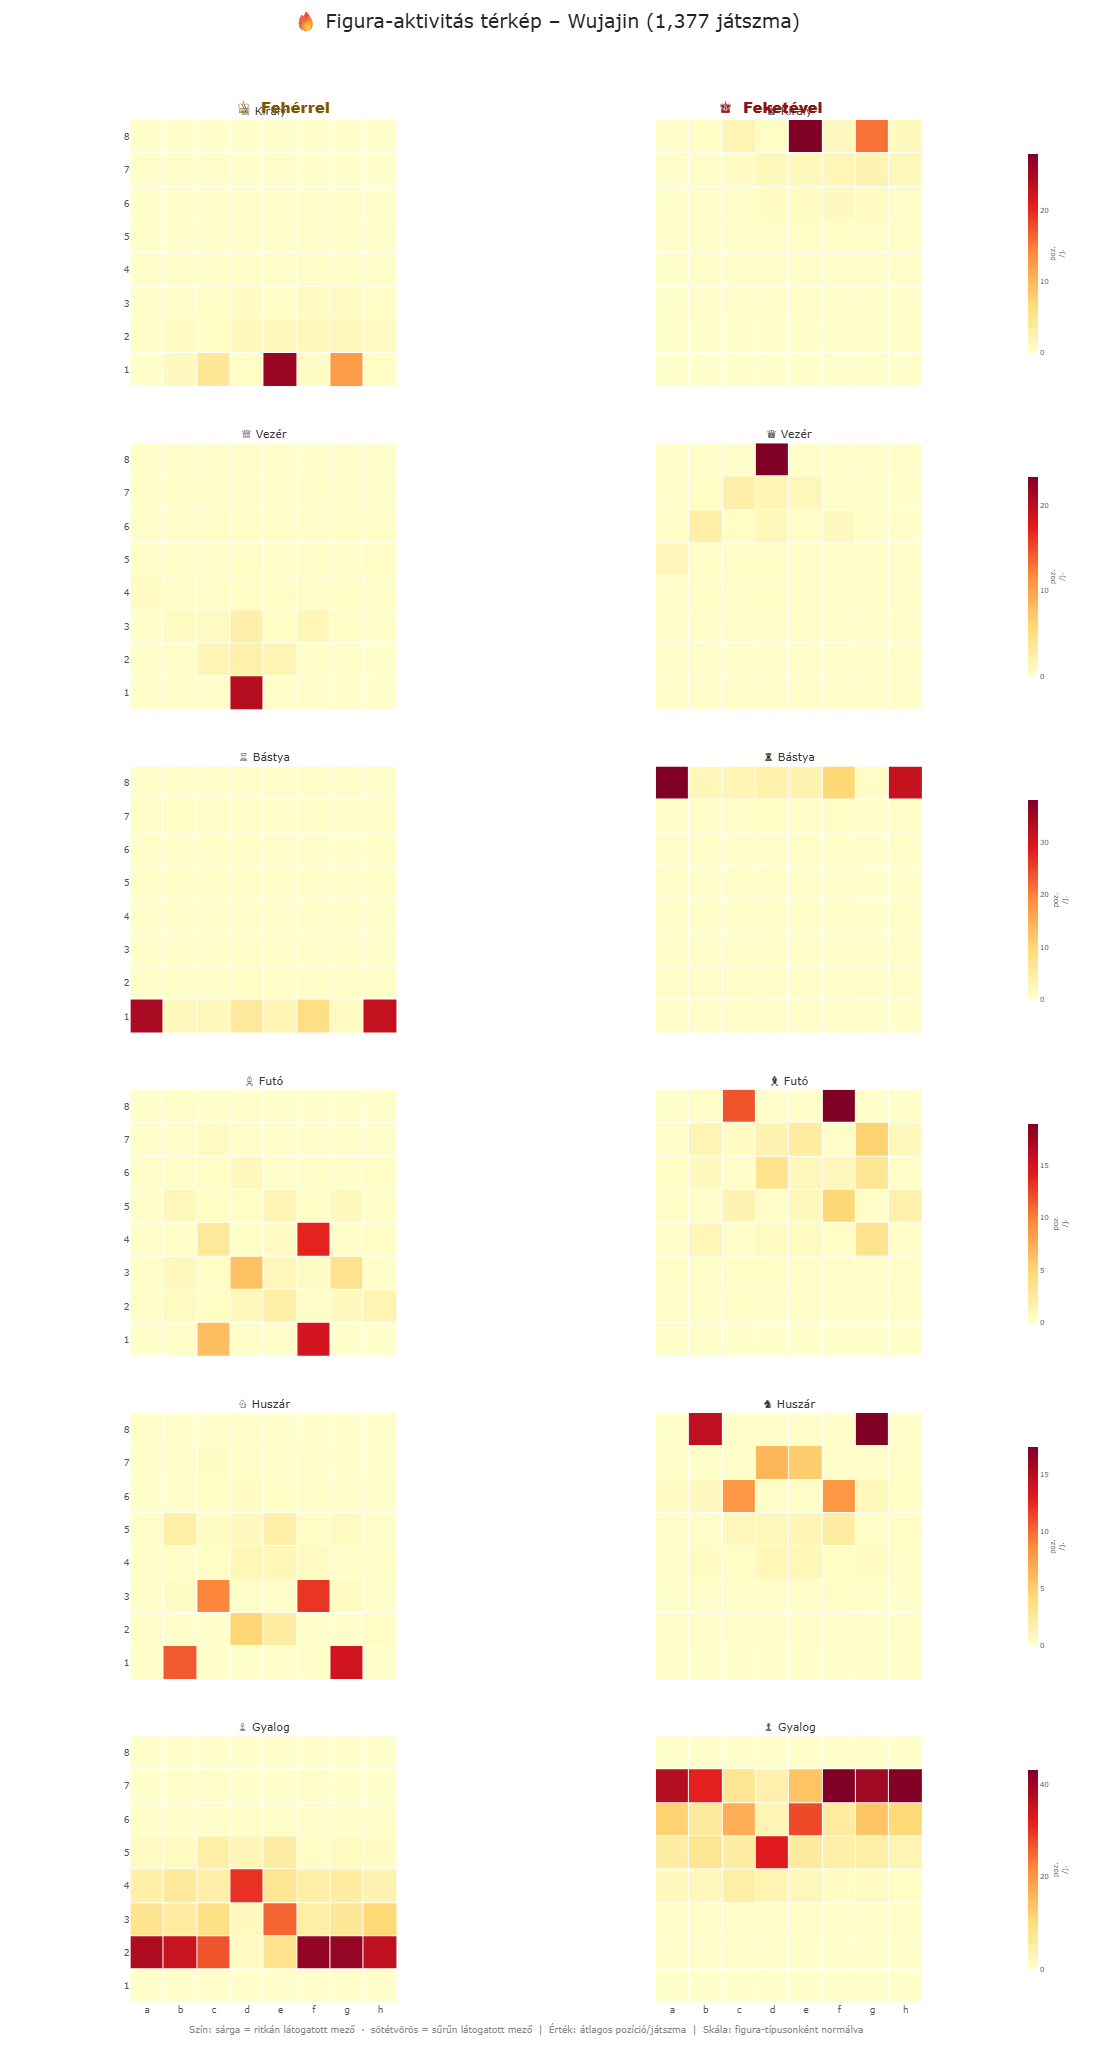

In [14]:
import chess
import chess.pgn
from collections import Counter
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# ── Játékos detektálás ────────────────────────────────────────────────────────
_pgn4 = os.path.join(root_dir, 'sakkpartik.pgn')
if not os.path.exists(_pgn4):
    _pgn4 = config.PGN_FILE

try:
    PLAYER
except NameError:
    _nc4 = Counter()
    with open(_pgn4, encoding='utf-8') as f:
        while (g := chess.pgn.read_game(f)):
            _nc4[g.headers.get('White', '')] += 1
            _nc4[g.headers.get('Black', '')] += 1
    PLAYER = _nc4.most_common(1)[0][0]

# ── Konstansok ────────────────────────────────────────────────────────────────
_PT_ORDER = [chess.KING, chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT, chess.PAWN]
_PT_HU = {
    chess.KING:   'Király',  chess.QUEEN:  'Vezér',
    chess.ROOK:   'Bástya',  chess.BISHOP: 'Futó',
    chess.KNIGHT: 'Huszár',  chess.PAWN:   'Gyalog',
}
_SYM_W = {
    chess.KING: '♔', chess.QUEEN: '♕', chess.ROOK: '♖',
    chess.BISHOP: '♗', chess.KNIGHT: '♘', chess.PAWN: '♙',
}
_SYM_B = {
    chess.KING: '♚', chess.QUEEN: '♛', chess.ROOK: '♜',
    chess.BISHOP: '♝', chess.KNIGHT: '♞', chess.PAWN: '♟',
}
_FILES_TEXT = list('abcdefgh')
_RANKS_TEXT = ['1', '2', '3', '4', '5', '6', '7', '8']
_NROWS = len(_PT_ORDER)

# ── Adatgyűjtés (mozgás utáni pozíciók mintavételezése) ──────────────────────
_hm = {
    'white': {pt: np.zeros((8, 8)) for pt in _PT_ORDER},
    'black': {pt: np.zeros((8, 8)) for pt in _PT_ORDER},
}
_gc4 = {'white': 0, 'black': 0}

with open(_pgn4, encoding='utf-8') as f:
    while (game := chess.pgn.read_game(f)):
        h = game.headers
        white, black = h.get('White', ''), h.get('Black', '')
        if white == PLAYER:
            side, pc = 'white', chess.WHITE
        elif black == PLAYER:
            side, pc = 'black', chess.BLACK
        else:
            continue
        _gc4[side] += 1
        board = game.board()
        for move in game.mainline_moves():
            board.push(move)
            for pt in _PT_ORDER:
                for sq in board.pieces(pt, pc):
                    _hm[side][pt][chess.square_rank(sq)][chess.square_file(sq)] += 1

# Normálás: pozíció / játszma
for _s in ('white', 'black'):
    if _gc4[_s] > 0:
        for pt in _PT_ORDER:
            _hm[_s][pt] /= _gc4[_s]

print(f'✅ Kész – Fehér: {_gc4["white"]} j., Fekete: {_gc4["black"]} j.')

# ── Layout paraméterek ────────────────────────────────────────────────────────
_HS  = 0.08    # vízszintes hézag az oszlopok közt (paper-frakció)
_VS  = 0.030   # függőleges hézag a sorok közt    (paper-frakció)
_cww = (1 - _HS) / 2                       # subplot szélesség paper-koordinátában
_crh = (1 - (_NROWS - 1) * _VS) / _NROWS  # subplot magasság paper-koordinátában

# Subplot-sorok colorbar Y-középpontjai
def _cb_y(ri):
    return 1.0 - (ri - 1) * (_crh + _VS) - _crh / 2

# Subplot-fejlécek (rövid, hogy ne lógjanak egymásra)
_subtitles = []
for pt in _PT_ORDER:
    _subtitles.append(f'{_SYM_W[pt]} {_PT_HU[pt]}')
    _subtitles.append(f'{_SYM_B[pt]} {_PT_HU[pt]}')

fig = make_subplots(
    rows=_NROWS, cols=2,
    subplot_titles=_subtitles,
    horizontal_spacing=_HS,
    vertical_spacing=_VS,
    column_widths=[0.5, 0.5],
)

# ── Traces hozzáadása ─────────────────────────────────────────────────────────
# Colorscale: sárga (alacsony) → sötétvörös (magas)
_CS = [[0.00, '#ffffcc'], [0.25, '#fed976'], [0.50, '#fd8d3c'],
       [0.75, '#e31a1c'], [1.00, '#800026']]

for ri, pt in enumerate(_PT_ORDER, start=1):
    # Közös max a két oszlophoz → összehasonlítható szín
    _zmax = max(_hm['white'][pt].max(), _hm['black'][pt].max())
    if _zmax == 0:
        _zmax = 1

    for ci, side in enumerate(('white', 'black'), start=1):
        z = _hm[side][pt]
        _show_cb = (ci == 2)  # colorbar csak a jobb oszlopban

        hover = [
            [f'<b>{_FILES_TEXT[fi]}{rank + 1}</b>: {z[rank][fi]:.2f} poz./játszma'
             for fi in range(8)]
            for rank in range(8)
        ]

        cb_kwargs = dict(
            colorbar=dict(
                y=_cb_y(ri),
                len=_crh * 0.82,
                yanchor='middle',
                x=1.005,
                thickness=10,
                tickfont=dict(size=7, color='#555'),
                title=dict(
                    text='poz.<br>/j.',
                    font=dict(size=7, color='#555'),
                    side='right',
                ),
                nticks=4,
                outlinewidth=0,
            )
        ) if _show_cb else {}

        fig.add_trace(
            go.Heatmap(
                z=z,
                x=list(range(8)),   # numerikus tengely → scaleanchor működik
                y=list(range(8)),
                colorscale=_CS,
                zmin=0,
                zmax=_zmax,
                showscale=_show_cb,
                xgap=1,
                ygap=1,
                text=hover,
                hovertemplate='%{text}<extra></extra>',
                **cb_kwargs,
            ),
            row=ri, col=ci,
        )

# ── Négyzetes cellák + tengelyfeliratok ───────────────────────────────────────
for ri in range(1, _NROWS + 1):
    for ci in range(1, 3):
        n     = (ri - 1) * 2 + ci
        xref  = 'x' if n == 1 else f'x{n}'
        # Csak az alsó sorban rajzolunk x-feliratot, y-felirat mindig bal oldal
        _show_x = (ri == _NROWS)
        _show_y = (ci == 1)

        fig.update_xaxes(
            tickmode='array',
            tickvals=list(range(8)),
            ticktext=_FILES_TEXT if _show_x else [''] * 8,
            showticklabels=_show_x,
            tickfont=dict(size=9, color='#555'),
            showgrid=False,
            zeroline=False,
            constrain='domain',
            row=ri, col=ci,
        )
        fig.update_yaxes(
            tickmode='array',
            tickvals=list(range(8)),
            ticktext=_RANKS_TEXT if _show_y else [''] * 8,
            showticklabels=_show_y,
            tickfont=dict(size=9, color='#555'),
            showgrid=False,
            zeroline=False,
            scaleanchor=xref,
            scaleratio=1,
            constrain='domain',
            row=ri, col=ci,
        )

# ── Subplot-fejléc fontméret csökkentése ─────────────────────────────────────
# Először (csak a make_subplots által létrehozott subplot-title annotációkra hat),
# az ezután add_annotation()-nel hozzáadott annotációk megtartják saját méretüket.
fig.update_annotations(font_size=11)

# ── Oszlopfejlécek (a plot terület FELETT, a top margin-ban) ─────────────────
fig.add_annotation(
    x=0.25, y=1.0, xref='paper', yref='paper',
    text='♔  Fehérrel',
    showarrow=False,
    font=dict(size=15, color='#7a5800', family='Arial Black'),
    xanchor='center', yanchor='bottom',
)
fig.add_annotation(
    x=0.75, y=1.0, xref='paper', yref='paper',
    text='♚  Feketével',
    showarrow=False,
    font=dict(size=15, color='#8b1414', family='Arial Black'),
    xanchor='center', yanchor='bottom',
)

# ── Jelmagyarázat (alul) ──────────────────────────────────────────────────────
fig.add_annotation(
    x=0.5, y=-0.01, xref='paper', yref='paper',
    text='Szín: sárga = ritkán látogatott mező  ·  sötétvörös = sűrűn látogatott mező  '
         '|  Érték: átlagos pozíció/játszma  |  Skála: figura-típusonként normálva',
    showarrow=False, font=dict(size=9, color='#888'),
    xanchor='center', yanchor='top',
)

# ── Figuraméretek: négyzetes boardhoz kiszámítva ──────────────────────────────
_W  = 700
_ml, _mr, _mt, _mb = 40, 80, 120, 45

_avail_w        = _W - _ml - _mr                  # 580 px
_subplot_px     = _cww * _avail_w                 # subplot szélesség px-ben
_avail_h_needed = _subplot_px / _crh              # szükséges magasság
_H              = int(_avail_h_needed) + _mt + _mb

fig.update_layout(
    title=dict(
        text=f'🔥 Figura-aktivitás térkép – {PLAYER} ({TOTAL:,} játszma)',
        font=dict(size=19, color='#222'),
        x=0.5, xanchor='center',
        y=0.993,
    ),
    width=_W,
    height=_H,
    template='plotly_white',
    paper_bgcolor='white',
    plot_bgcolor='white',
    showlegend=False,
    font=dict(color='#333', size=11),
    margin=dict(l=_ml, r=_mr, t=_mt, b=_mb),
)

print(f'Ábra: {_W} × {_H} px  |  szubplot ≈ {int(_subplot_px)} × {int(_subplot_px)} px')
fig.show()
# fig.write_html(os.path.join(config.PLOTS_DIR, 'piece_heatmap.html'))
